In [42]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [43]:
#import Lib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
#Loading data
tra_df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Project/Data/train.csv', index_col='Loan_ID')
te_df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Project/Data/test.csv', index_col='Loan_ID')

In [45]:
tra_df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y


In [46]:
#Kiểm tra missing
tra_df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [47]:
tra_df['Gender'] = tra_df['Gender'].fillna(tra_df['Gender'].mode()[0])
tra_df['Married'] = tra_df['Married'].fillna(tra_df['Married'].mode()[0])
tra_df['Dependents'] = tra_df['Dependents'].fillna(tra_df['Dependents'].mode()[0])
tra_df['LoanAmount'] = tra_df['LoanAmount'].fillna(tra_df['LoanAmount'].mean())
tra_df['Self_Employed'] = tra_df['Self_Employed'].fillna(tra_df['Self_Employed'].mode()[0])
tra_df['Credit_History'] = tra_df['Credit_History'].fillna(tra_df['Credit_History'].mode()[0])
tra_df['Loan_Amount_Term'] = tra_df['Loan_Amount_Term'].fillna(tra_df['Loan_Amount_Term'].mode()[0])
tra_df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [48]:
#Chuyển các biến Category về biến giả(dummy)
tra_df['Loan_Status'] = np.where(tra_df.Loan_Status == 'Y',1,0)
tra_df['Gender'] = np.where(tra_df.Gender == 'Male',1,0)
tra_df['Married'] = np.where(tra_df.Married == 'Yes',1,0)
tra_df['Education'] = np.where(tra_df.Education == 'Graduate',1,0)
tra_df['Self_Employed'] = np.where(tra_df.Self_Employed == 'Yes',1,0)
tra_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,146.412162,360.0,1.0,Urban,1
LP001003,1,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,Rural,0
LP001005,1,1,0,1,1,3000,0.0,66.000000,360.0,1.0,Urban,1
LP001006,1,1,0,0,0,2583,2358.0,120.000000,360.0,1.0,Urban,1
LP001008,1,0,0,1,0,6000,0.0,141.000000,360.0,1.0,Urban,1


In [49]:
#Chuyển biến Property_Area,Dependents thành dummy
tra_df = pd.get_dummies(tra_df, columns=['Property_Area'], dtype=int, drop_first=True)
tra_df = pd.get_dummies(tra_df, columns=['Dependents'], dtype=int, drop_first=True)
tra_df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban,Dependents_1,Dependents_2,Dependents_3+
Loan_ID,,,,,,,,,,,,,,,
LP001002,1,0,1,0,5849,0.0,146.412162,360.0,1.0,1,0,1,0,0,0
LP001003,1,1,1,0,4583,1508.0,128.000000,360.0,1.0,0,0,0,1,0,0
LP001005,1,1,1,1,3000,0.0,66.000000,360.0,1.0,1,0,1,0,0,0
LP001006,1,1,0,0,2583,2358.0,120.000000,360.0,1.0,1,0,1,0,0,0
LP001008,1,0,1,0,6000,0.0,141.000000,360.0,1.0,1,0,1,0,0,0


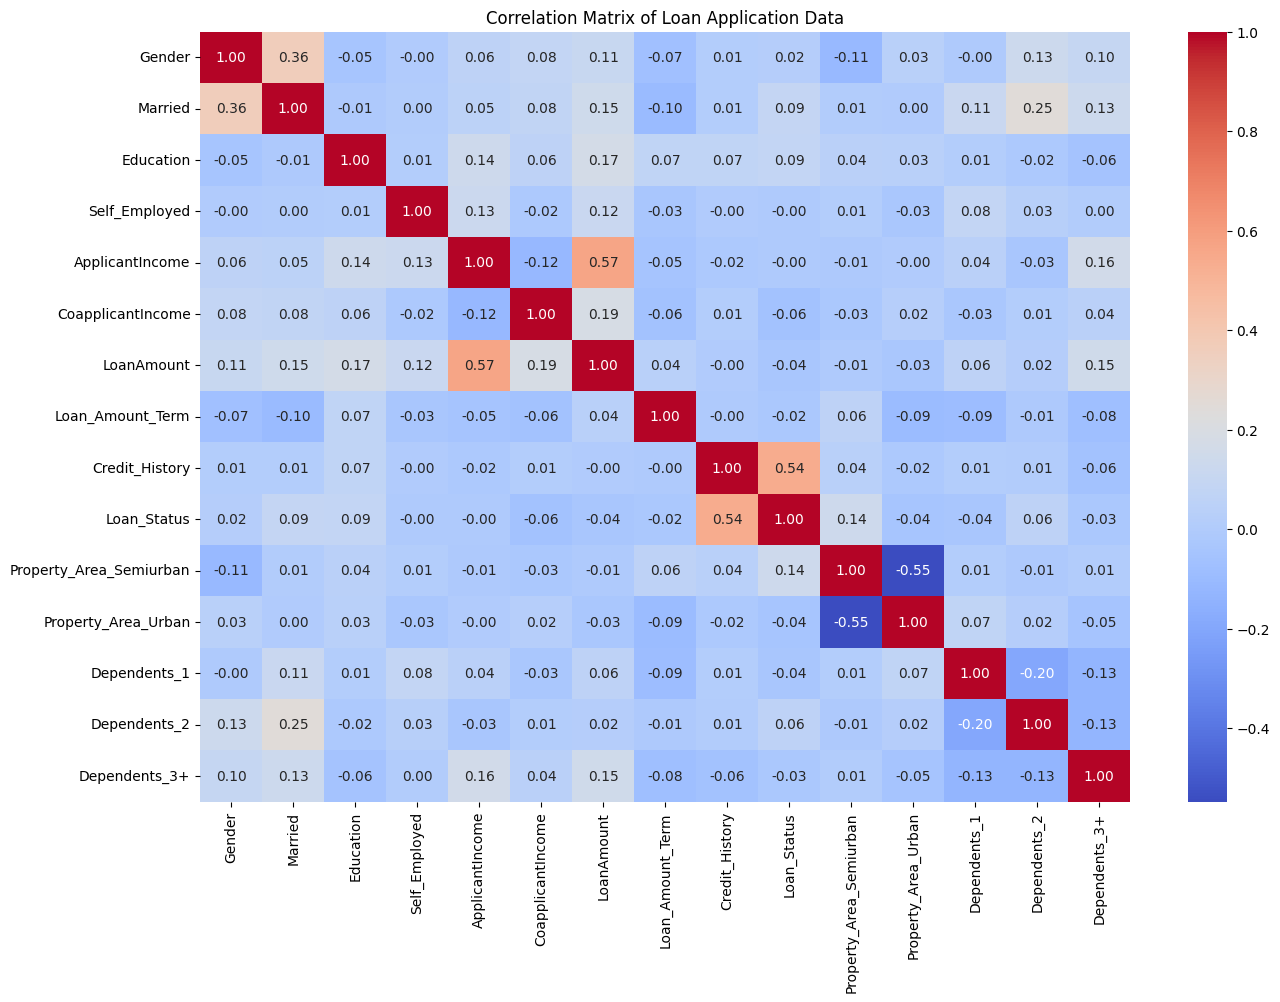

In [50]:
correlation_matrix = tra_df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Loan Application Data')
plt.show()

### Visualization of numerical features with Boxplots

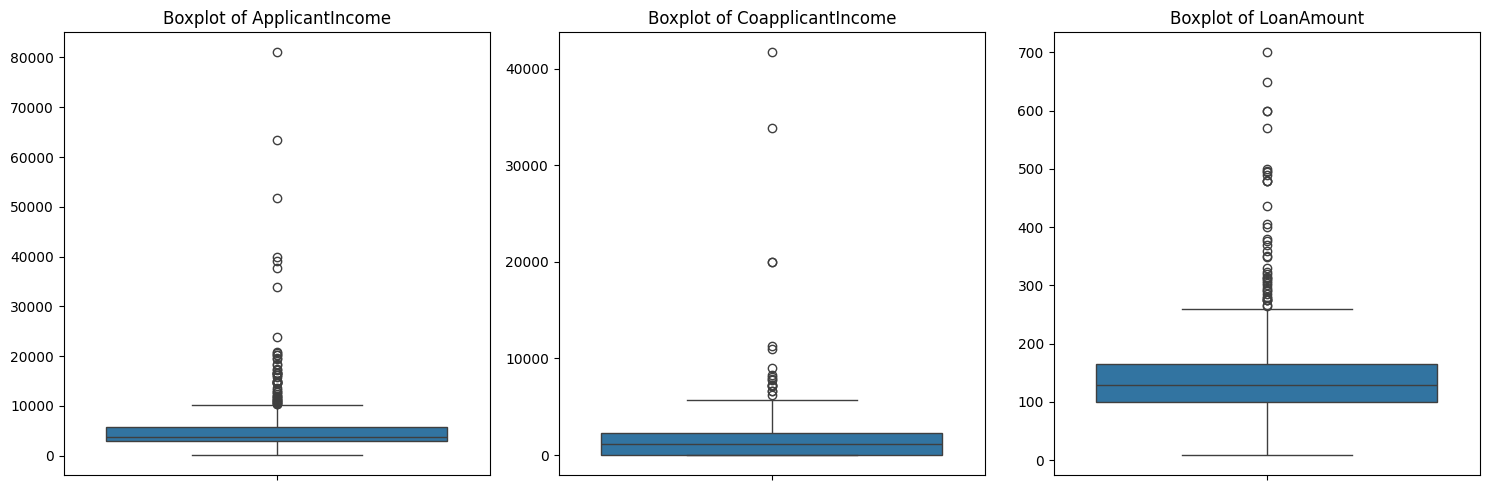

In [51]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=tra_df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Handling outliers using IQR method (Capping)

Outliers in numerical columns have been capped using the IQR method.


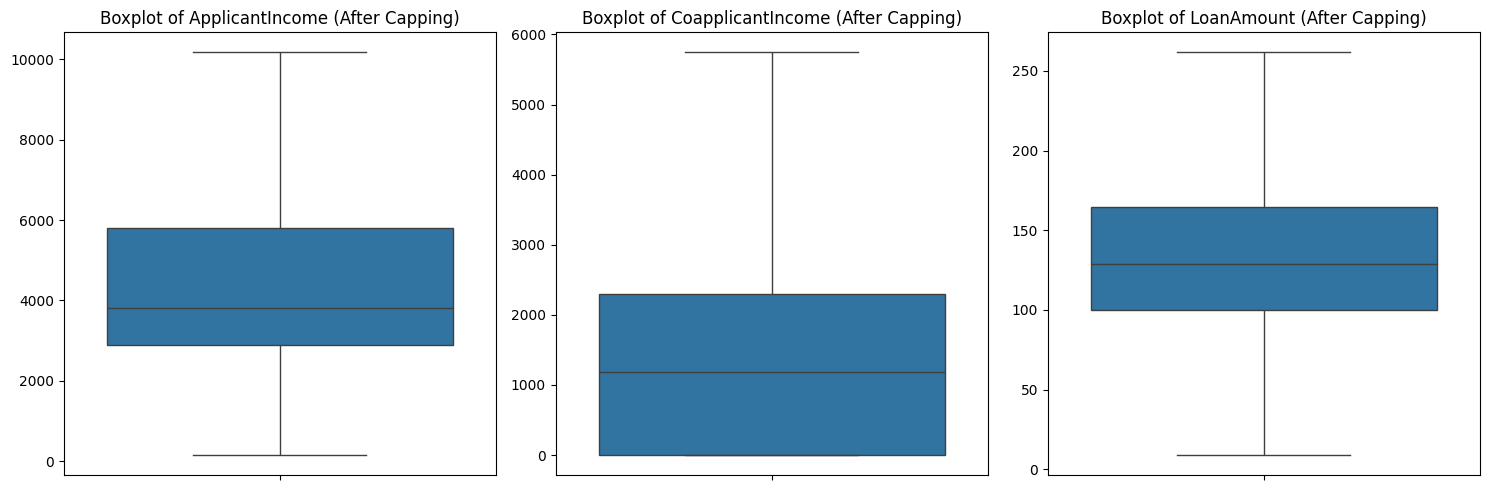

In [52]:
for col in numerical_cols:
    Q1 = tra_df[col].quantile(0.25)
    Q3 = tra_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    tra_df[col] = np.where(tra_df[col] < lower_bound, lower_bound, tra_df[col])
    tra_df[col] = np.where(tra_df[col] > upper_bound, upper_bound, tra_df[col])

print("Outliers in numerical columns have been capped using the IQR method.")

# Visualize again after capping
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=tra_df[col])
    plt.title(f'Boxplot of {col} (After Capping)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [53]:
X = tra_df.drop(['Loan_Status'], axis=1)
X

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban,Dependents_1,Dependents_2,Dependents_3+
Loan_ID,,,,,,,,,,,,,,
LP001002,1,0,1,0,5849.0,0.0,146.412162,360.0,1.0,0,1,0,0,0
LP001003,1,1,1,0,4583.0,1508.0,128.000000,360.0,1.0,0,0,1,0,0
LP001005,1,1,1,1,3000.0,0.0,66.000000,360.0,1.0,0,1,0,0,0
LP001006,1,1,0,0,2583.0,2358.0,120.000000,360.0,1.0,0,1,0,0,0
LP001008,1,0,1,0,6000.0,0.0,141.000000,360.0,1.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LP002978,0,0,1,0,2900.0,0.0,71.000000,360.0,1.0,0,0,0,0,0
LP002979,1,1,1,0,4106.0,0.0,40.000000,180.0,1.0,0,0,0,0,1
LP002983,1,1,1,0,8072.0,240.0,253.000000,360.0,1.0,0,1,1,0,0


In [54]:
y = tra_df['Loan_Status']
y

,Loan_Status
Loan_ID,
LP001002,1
LP001003,0
LP001005,1
LP001006,1
LP001008,1
...,...
LP002978,1
LP002979,1
LP002983,1


In [55]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state = 1)

In [56]:
# Danh sách các mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Random Forest": RandomForestClassifier(random_state=1)
}
#Huấn luyện và dự đoán
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression ---
Accuracy: 0.8049
              precision    recall  f1-score   support

           0       0.94      0.41      0.57        39
           1       0.78      0.99      0.87        84

    accuracy                           0.80       123
   macro avg       0.86      0.70      0.72       123
weighted avg       0.83      0.80      0.78       123

--- Decision Tree ---
Accuracy: 0.6829
              precision    recall  f1-score   support

           0       0.50      0.56      0.53        39
           1       0.78      0.74      0.76        84

    accuracy                           0.68       123
   macro avg       0.64      0.65      0.65       123
weighted avg       0.69      0.68      0.69       123

--- Random Forest ---
Accuracy: 0.7886
              precision    recall  f1-score   support

           0       0.81      0.44      0.57        39
           1       0.78      0.95      0.86        84

    accuracy                           0.79       123
   ma

Logistic Regression có Accuracy cao nhất (80%), nhưng hãy nhìn vào Recall của lớp 0 (0.41). Dùng SMOTE để kiểm tra kĩ hơn

In [57]:
# 1. Khởi tạo SMOTE
sm = SMOTE(random_state=1)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_res, y_train_res)

y_pred_smote = lr_smote.predict(X_test)

print("Tỷ lệ các lớp sau khi SMOTE:", pd.Series(y_train_res).value_counts())
print(classification_report(y_test, y_pred_smote))

Tỷ lệ các lớp sau khi SMOTE: Loan_Status
0    338
1    338
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.66      0.64      0.65        39
           1       0.84      0.85      0.84        84

    accuracy                           0.78       123
   macro avg       0.75      0.74      0.74       123
weighted avg       0.78      0.78      0.78       123



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Recall đã tăng lên giúp hạn chế được nhiều rủi ro hơn

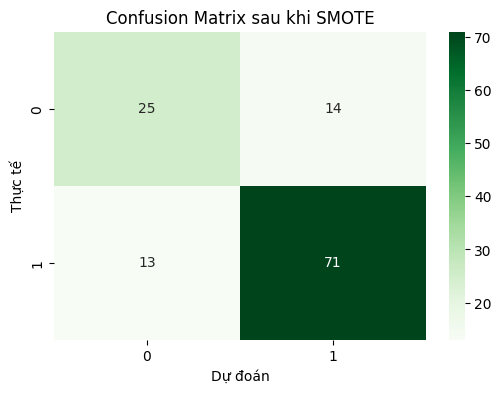

In [58]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6,4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix sau khi SMOTE')
plt.show()

In [59]:
#Xử lý dữ liệu file test
te_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [60]:
te_df.isnull().sum()/len(te_df)*100

,0
Gender,2.997275
Married,0.000000
Dependents,2.724796
Education,0.000000
Self_Employed,6.267030
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,1.362398
Loan_Amount_Term,1.634877
Credit_History,7.901907


In [61]:
te_df['Gender'] = te_df['Gender'].fillna(te_df['Gender'].mode()[0])
te_df['Dependents'] = te_df['Dependents'].fillna(te_df['Dependents'].mode()[0])
te_df['Self_Employed'] = te_df['Self_Employed'].fillna(te_df['Self_Employed'].mode()[0])
te_df['LoanAmount'] = te_df['LoanAmount'].fillna(tra_df['LoanAmount'].mean())
te_df['Credit_History'] = te_df['Credit_History'].fillna(te_df['Credit_History'].mode()[0])
te_df['Loan_Amount_Term'] = te_df['Loan_Amount_Term'].fillna(te_df['Loan_Amount_Term'].mode()[0])

In [62]:
#Chuyển các biến Category về biến giả(dummy)
te_df['Gender'] = np.where(te_df.Gender == 'Male',1,0)
te_df['Married'] = np.where(te_df.Married == 'Yes',1,0)
te_df['Education'] = np.where(te_df.Education == 'Graduate',1,0)
te_df['Self_Employed'] = np.where(te_df.Self_Employed == 'Yes',1,0)

In [63]:
#Xử lý missing
te_df['LoanAmount'] = te_df['LoanAmount'].fillna(te_df['LoanAmount'].mean())
te_df['Credit_History'] = te_df['Credit_History'].fillna(te_df['Credit_History'].mode()[0])
te_df['Loan_Amount_Term'] = te_df['Loan_Amount_Term'].fillna(te_df['Loan_Amount_Term'].mode()[0])

In [64]:
#Chuyển biến Property_Area,Dependents thành dummy
te_df = pd.get_dummies(te_df, columns=['Property_Area'], dtype=int, drop_first=True)
te_df = pd.get_dummies(te_df, columns=['Dependents'], dtype=int, drop_first=True)
te_df.isnull().sum()

,0
Gender,0
Married,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0
Property_Area_Semiurban,0


In [65]:
te_df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban,Dependents_1,Dependents_2,Dependents_3+
Loan_ID,,,,,,,,,,,,,,
LP001015,1,1,1,0,5720,0,110.0,360.0,1.0,0,1,0,0,0
LP001022,1,1,1,0,3076,1500,126.0,360.0,1.0,0,1,1,0,0
LP001031,1,1,1,0,5000,1800,208.0,360.0,1.0,0,1,0,1,0
LP001035,1,1,1,0,2340,2546,100.0,360.0,1.0,0,1,0,1,0
LP001051,1,0,0,0,3276,0,78.0,360.0,1.0,0,1,0,0,0


In [66]:
# Lấy những cột mà mô hình (X_train) đã dùng để học
features = X_train.columns
X_test_final = te_df[features]

      Loan_ID Loan_Status_Predicted
0    LP001015                     Y
1    LP001022                     Y
2    LP001031                     Y
3    LP001035                     Y
4    LP001051                     N
..        ...                   ...
362  LP002971                     Y
363  LP002975                     Y
364  LP002980                     Y
365  LP002986                     Y
366  LP002989                     Y

[367 rows x 2 columns]


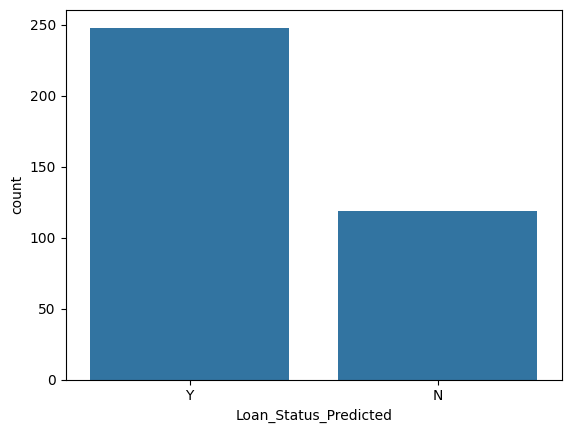

In [67]:
# Dự báo kết quả (0 hoặc 1)
predictions = lr_smote.predict(X_test_final)

# Tạo dataframe kết quả
final_output = pd.DataFrame({
    'Loan_ID': te_df.index,
    'Loan_Status_Predicted': predictions
})

# Chuyển ngược lại 1 -> 'Y', 0 -> 'N' cho dễ đọc
final_output['Loan_Status_Predicted'] = final_output['Loan_Status_Predicted'].map({1: 'Y', 0: 'N'})
print(final_output)
sns.countplot(data=final_output, x='Loan_Status_Predicted')
plt.show()